In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
import matplotlib
matplotlib.rcParams["figure.figsize"] = (20,10)

In [3]:
df = pd.read_csv('Chennai_Price_Prediction.csv')
print("First Five Row")
df.head()

First Five Row


,price,area,status,bhk,bathroom,age,location,builder
0,37.49,872,Ready to move,2,NaN,1.0,Sembakkam,MP Developers
1,93.54,1346,Under Construction,3,2.0,NaN,Selaiyur,DAC Promoters
2,151.00,2225,Under Construction,3,NaN,0.0,Mogappair,Casagrand Builder Private Limited
3,49.00,1028,Ready to move,2,2.0,3.0,Ambattur,Dugar Housing Builders
4,42.28,588,Under Construction,2,1.0,0.0,Pallavaram,Radiance Realty Developers India Ltd


In [4]:
print("Dimension of given Dataset")
df.shape

Dimension of given Dataset


(2620, 8)

In [5]:
df.groupby('location')['location'].agg('count')

location
Adambakam         8
Adyar            11
Agaramthen        7
Alandur           5
Alwarpet         11
                 ..
Virugambakkam     8
Washermanpet      1
West Mambalam    47
West Tambaram     7
tambaram west    14
Name: location, Length: 178, dtype: int64

In [8]:
df = df.drop(['status','age','builder'],axis='columns')
df.head()

,price,area,bhk,bathroom,location
0,37.49,872,2,NaN,Sembakkam
1,93.54,1346,3,2.0,Selaiyur
2,151.00,2225,3,NaN,Mogappair
3,49.00,1028,2,2.0,Ambattur
4,42.28,588,2,1.0,Pallavaram


In [9]:
df.isnull().sum()

price          0
area           0
bhk            0
bathroom    1217
location       0
dtype: int64

In [10]:
df['bathroom'] = df.groupby('bhk')['bathroom'].transform(
    lambda x: x.fillna(x.median())
)

In [11]:
df.isnull().sum()

price       0
area        0
bhk         0
bathroom    0
location    0
dtype: int64

In [12]:
df['bhk'].unique()

array([2, 3, 4, 1, 5, 6, 8])

In [14]:
df[df.bhk > 5]

,price,area,bhk,bathroom,location
1171,165.0,3000,6,4.0,Madipakkam
1378,140.0,2200,6,4.0,Kolathur
1388,140.0,2590,6,4.0,Kolathur
1711,1050.0,4200,6,6.0,T Nagar
1857,490.0,4500,8,6.0,Royapettah
1900,490.0,4500,8,6.0,Royapettah


In [15]:
df.area.unique()

array([ 872, 1346, 2225, ..., 1127, 1131,  898], shape=(1011,))

In [19]:
df['area'] = pd.to_numeric(df['area'], errors='coerce')

In [20]:
df1 = df.copy()
df1.head(3)

,price,area,bhk,bathroom,location
0,37.49,872,2,2.0,Sembakkam
1,93.54,1346,3,2.0,Selaiyur
2,151.00,2225,3,3.0,Mogappair


In [21]:
df1.loc[30]

price           57.5
area             920
bhk                2
bathroom         1.0
location    Ambattur
Name: 30, dtype: object

In [22]:
df2 = df1.copy()
df2['price_per_sqft'] = df2['price'] * 100000 / df2['area']
df2.head()

,price,area,bhk,bathroom,location,price_per_sqft
0,37.49,872,2,2.0,Sembakkam,4299.311927
1,93.54,1346,3,2.0,Selaiyur,6949.479941
2,151.00,2225,3,3.0,Mogappair,6786.516854
3,49.00,1028,2,2.0,Ambattur,4766.536965
4,42.28,588,2,1.0,Pallavaram,7190.476190


In [23]:
len(df2.location.unique())

178

In [24]:
df2.location = df2.location.apply(lambda x: x.strip())

location_stats = df2.groupby('location')['location'].agg('count').sort_values(ascending=False)
location_stats

location
Veppampattu       149
Pammal            139
Medavakkam        111
Sholinganallur     99
Perungudi          88
                 ... 
Ponniammanmedu      1
Thiruvidandhai      1
Vellakkal           1
Villivakkam         1
Washermanpet        1
Name: location, Length: 178, dtype: int64

In [25]:
len(location_stats[location_stats<10])

116

In [26]:
location_stats_less_than_10 = location_stats[location_stats<=10]
location_stats_less_than_10


location
Thandalam                     10
Ambattur INDUSTRIAL ESTATE    10
Urapakkam                     10
Kanathur Reddikuppam           9
Ayapakkam                      9
                              ..
Ponniammanmedu                 1
Thiruvidandhai                 1
Vellakkal                      1
Villivakkam                    1
Washermanpet                   1
Name: location, Length: 119, dtype: int64

In [27]:
len(df2.location.unique())

178

In [28]:
df2.location = df2.location.apply(lambda x : "other" if x in location_stats_less_than_10 else x)
len(df2.location.unique())

60

In [29]:
df2.head(10)

,price,area,bhk,bathroom,location,price_per_sqft
0,37.49,872,2,2.0,Sembakkam,4299.311927
1,93.54,1346,3,2.0,Selaiyur,6949.479941
2,151.00,2225,3,3.0,Mogappair,6786.516854
3,49.00,1028,2,2.0,Ambattur,4766.536965
4,42.28,588,2,1.0,Pallavaram,7190.476190
5,188.00,2221,3,3.0,other,8464.655561
6,38.00,885,3,3.0,Thirumazhisai,4293.785311
7,72.99,936,3,3.0,other,7798.076923
8,125.00,2275,4,4.0,other,5494.505495
9,24.56,622,2,2.0,Perungalathur,3948.553055


In [31]:
df3= df2[~(df2.area/df2.bhk<300)]
df3.shape

(2593, 6)

In [32]:
df3.price_per_sqft.describe()

count     2593.000000
mean      6396.745568
std       3422.929203
min       1743.119266
25%       4606.060606
50%       5417.177914
75%       6640.625000
max      26086.956522
Name: price_per_sqft, dtype: float64

In [33]:
def remove_pps_outlier(df):
    df_out = pd.DataFrame()
    for key, subdf in df.groupby('location'):
        m = np.mean(subdf.price_per_sqft)
        std = np.std(subdf.price_per_sqft)
        reduced_df = subdf[(subdf.price_per_sqft>(m-std))&(subdf.price_per_sqft<=(m+std))]
        df_out = pd.concat([df_out, reduced_df],ignore_index=True)
    return df_out
df4 = remove_pps_outlier(df3)
df4.shape

(2011, 6)

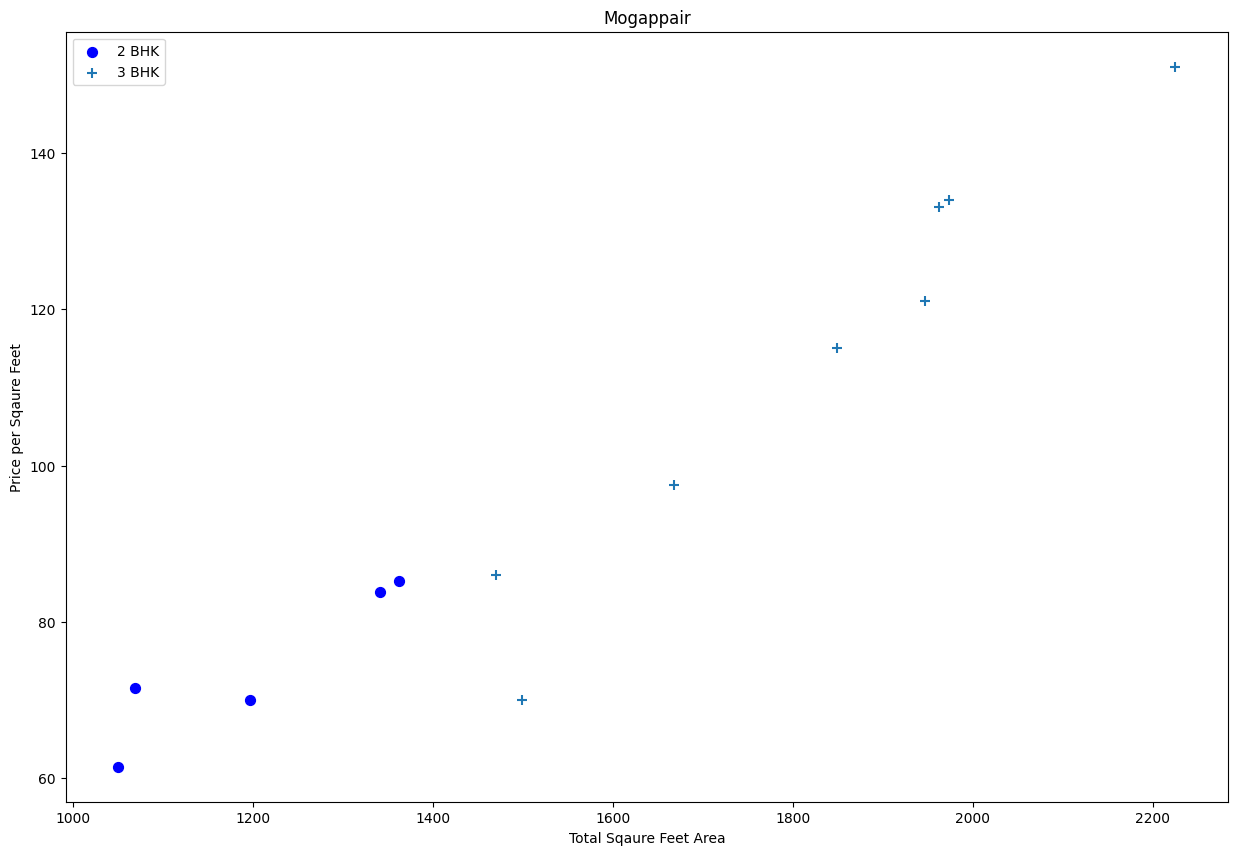

In [36]:
def plot_scatter_chart(df,location):
    bhk2 = df[(df.location==location)& (df.bhk==2)]
    bhk3 = df[(df.location==location)& (df.bhk==3)]
    matplotlib.rcParams['figure.figsize'] = (15,10)
    plt.scatter(bhk2.area,bhk2.price,color='blue',label='2 BHK',s=50)
    plt.scatter(bhk3.area,bhk3.price,marker='+',label='3 BHK',s=50)
    plt.xlabel("Total Sqaure Feet Area")
    plt.ylabel("Price per Sqaure Feet")
    plt.title(location)
    plt.legend()
plot_scatter_chart(df4,"Mogappair")

In [37]:
def remove_bhk_outlier(df):
    exclude_indices = np.array([])
    for location, location_df in df.groupby('location'):
        bhk_stats = {}
        for bhk, bhk_df in location_df.groupby('bhk'):
            bhk_stats[bhk] = {
                'mean' : np.mean(bhk_df.price_per_sqft),
                'std' : np.std(bhk_df.price_per_sqft),
                'count' : bhk_df.shape[0]
            }

        for bhk, bhk_df in location_df.groupby('bhk'):
            stats = bhk_stats.get(bhk-1)
            if stats and stats['count'] > 5:
                exclude_indices = np.append(exclude_indices, bhk_df[bhk_df.price_per_sqft<(stats['mean'])].index.values)    
    return df.drop(exclude_indices, axis='index')
df5 = remove_bhk_outlier(df4)
df5.shape

(1592, 6)

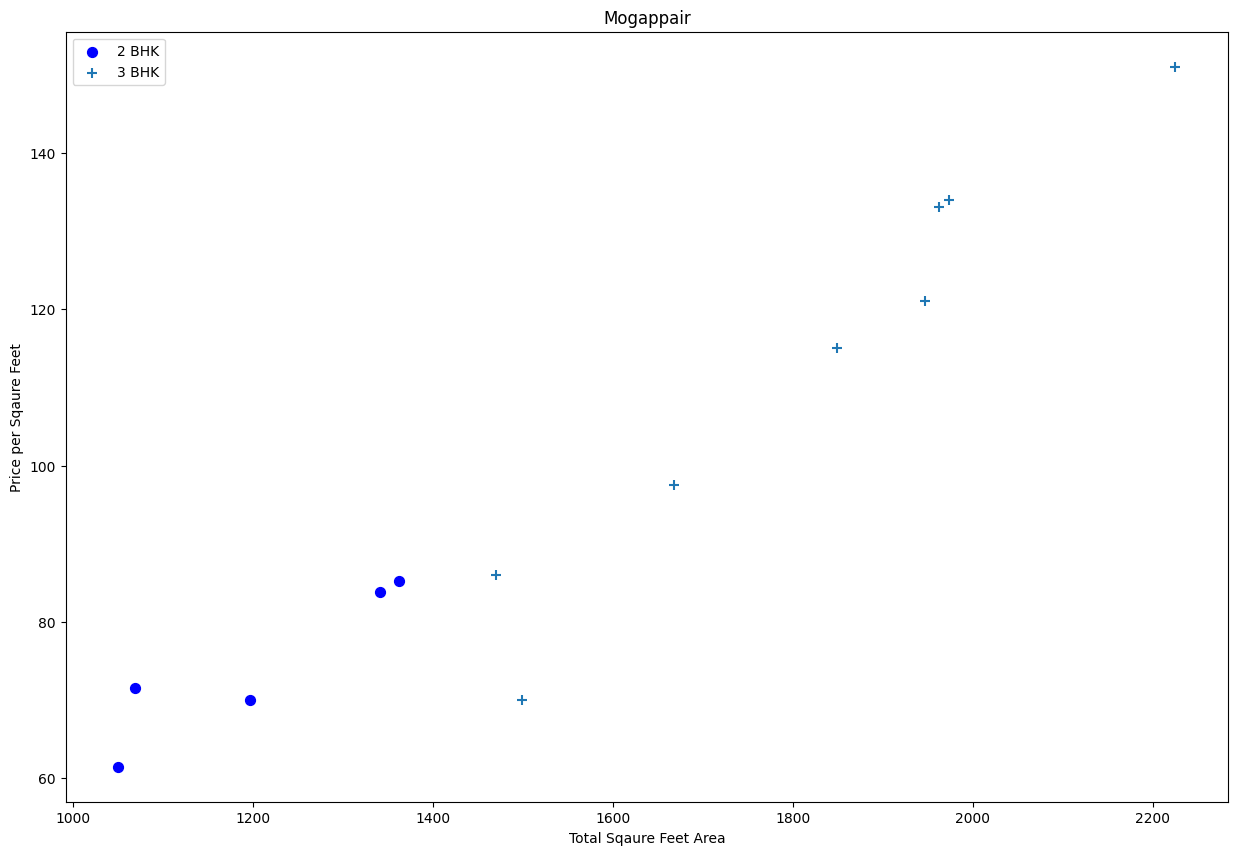

In [38]:
plot_scatter_chart(df5,"Mogappair")

Text(0, 0.5, 'Count')

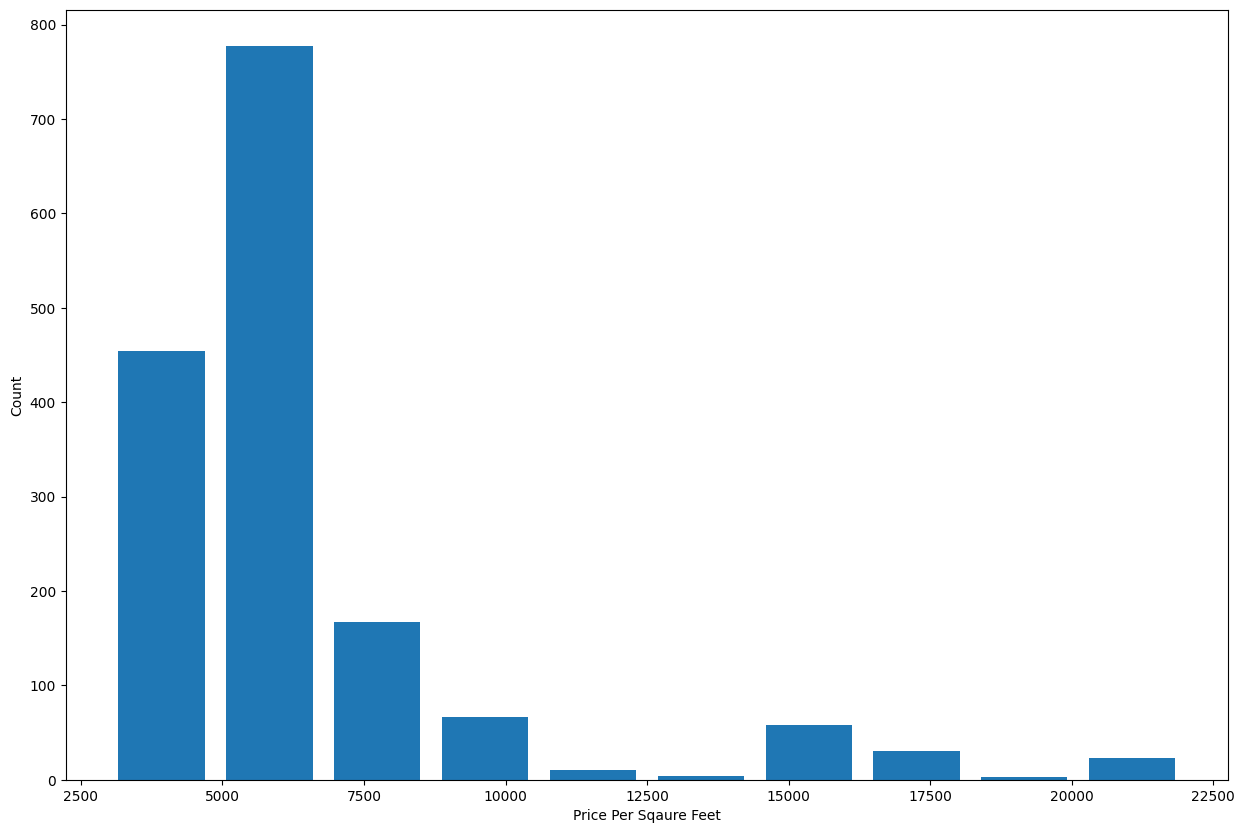

In [39]:
plt.hist(df5.price_per_sqft,rwidth=0.8)
plt.xlabel("Price Per Sqaure Feet")
plt.ylabel("Count")

In [40]:
df5.bathroom.unique()

array([3., 4., 2., 1., 5.])

In [44]:
df5[df5.bathroom > 3]

,price,area,bhk,bathroom,location,price_per_sqft
10,612.0,2781,4,4.0,Alwarpet,22006.472492
11,597.0,2713,4,4.0,Alwarpet,22005.160339
14,903.0,4302,4,4.0,Alwarpet,20990.237099
15,903.0,4302,4,4.0,Alwarpet,20990.237099
162,105.0,1360,4,4.0,East Tambaram,7720.588235
...,...,...,...,...,...,...
1731,160.0,2300,4,4.0,other,6956.521739
1745,390.0,4000,4,4.0,other,9750.000000
1753,350.0,4361,4,4.0,other,8025.682183
1877,260.0,3485,5,5.0,other,7460.545194


Text(0, 0.5, 'Count')

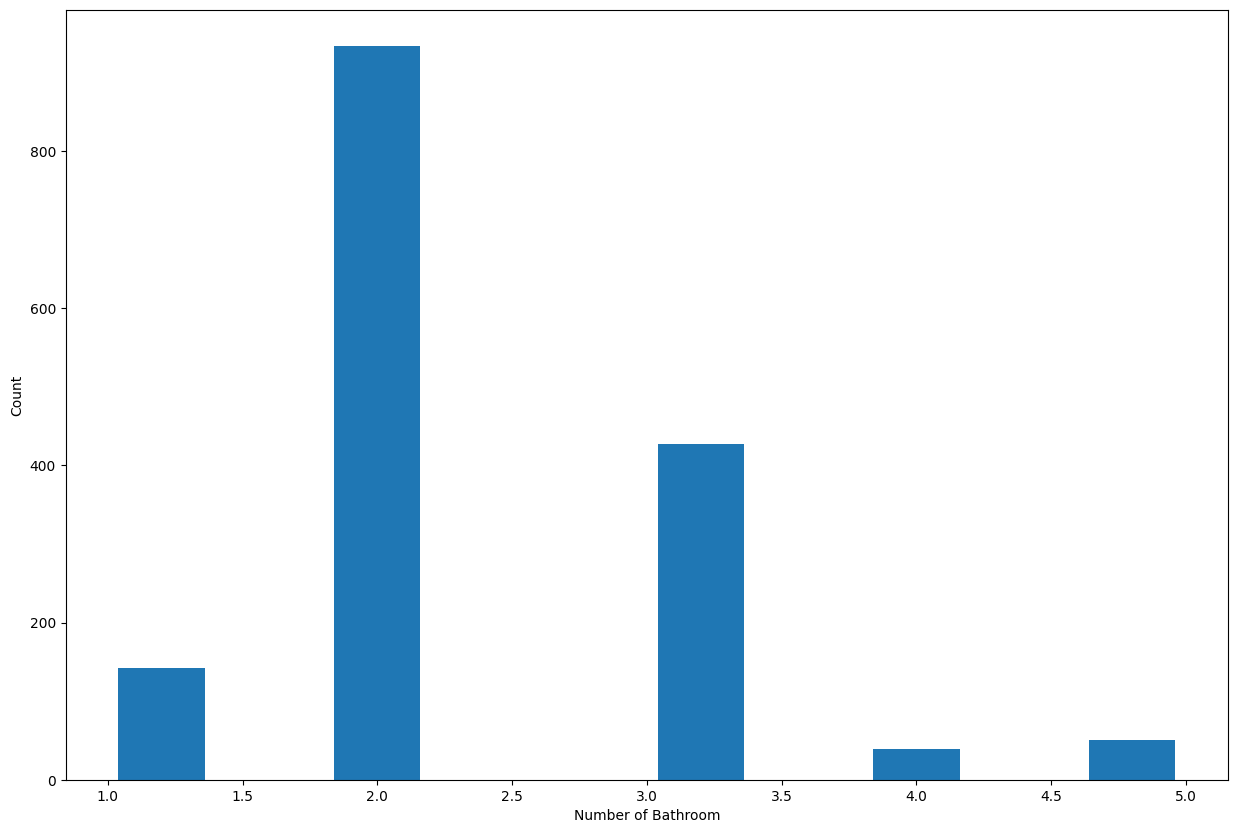

In [45]:
plt.hist(df5.bathroom,rwidth=0.8)
plt.xlabel("Number of Bathroom")
plt.ylabel("Count")

In [50]:
df5[df5.bathroom<df5.bhk+2]

,price,area,bhk,bathroom,location,price_per_sqft
0,261.00,1548,3,3.0,Adyar,16860.465116
1,278.00,1652,3,3.0,Adyar,16828.087167
2,274.00,1627,3,3.0,Adyar,16840.811309
3,210.00,1381,3,3.0,Adyar,15206.372194
6,230.00,1755,3,3.0,Adyar,13105.413105
...,...,...,...,...,...,...
2006,85.00,1621,3,3.0,tambaram west,5243.676743
2007,66.08,1180,3,3.0,tambaram west,5600.000000
2008,57.12,1020,2,2.0,tambaram west,5600.000000
2009,52.08,930,2,2.0,tambaram west,5600.000000


In [51]:
df6 = df5[df5.bathroom<df5.bhk+2]
df6.shape

(1591, 6)

In [52]:
df7 = df6.drop(['price_per_sqft'],axis='columns')
df7.head()

,price,area,bhk,bathroom,location
0,261.0,1548,3,3.0,Adyar
1,278.0,1652,3,3.0,Adyar
2,274.0,1627,3,3.0,Adyar
3,210.0,1381,3,3.0,Adyar
6,230.0,1755,3,3.0,Adyar


In [53]:
dummies = pd.get_dummies(df7.location,dtype=int)
dummies.head(3)

,Adyar,Alwarpet,Ambattur,Anna Nagar,Ayanambakkam,Chromepet,East Tambaram,Gerugambakkam,Gowrivakkam,Guduvancheri,...,Tiruvottiyur,Vadanemmeli,Vadapalani,Vanagaram,Velachery,Vengaivasal,Veppampattu,West Mambalam,other,tambaram west
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [54]:
df8 = pd.concat([df7,dummies.drop('other',axis="columns")],axis="columns")
df8.head()                

,price,area,bhk,bathroom,location,Adyar,Alwarpet,Ambattur,Anna Nagar,Ayanambakkam,...,Thirumullaivoyal,Tiruvottiyur,Vadanemmeli,Vadapalani,Vanagaram,Velachery,Vengaivasal,Veppampattu,West Mambalam,tambaram west
0,261.0,1548,3,3.0,Adyar,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,278.0,1652,3,3.0,Adyar,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,274.0,1627,3,3.0,Adyar,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,210.0,1381,3,3.0,Adyar,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,230.0,1755,3,3.0,Adyar,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [55]:
df9 = df8.drop('location',axis='columns')
df9.head()                

,price,area,bhk,bathroom,Adyar,Alwarpet,Ambattur,Anna Nagar,Ayanambakkam,Chromepet,...,Thirumullaivoyal,Tiruvottiyur,Vadanemmeli,Vadapalani,Vanagaram,Velachery,Vengaivasal,Veppampattu,West Mambalam,tambaram west
0,261.0,1548,3,3.0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,278.0,1652,3,3.0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,274.0,1627,3,3.0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,210.0,1381,3,3.0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,230.0,1755,3,3.0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [56]:
df9.shape

(1591, 63)

In [57]:
X = df9.drop('price',axis='columns')
X.head()

,area,bhk,bathroom,Adyar,Alwarpet,Ambattur,Anna Nagar,Ayanambakkam,Chromepet,East Tambaram,...,Thirumullaivoyal,Tiruvottiyur,Vadanemmeli,Vadapalani,Vanagaram,Velachery,Vengaivasal,Veppampattu,West Mambalam,tambaram west
0,1548,3,3.0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1652,3,3.0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1627,3,3.0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1381,3,3.0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,1755,3,3.0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [58]:
y = df9.price
y.head()

0    261.0
1    278.0
2    274.0
3    210.0
6    230.0
Name: price, dtype: float64

In [59]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=10)

In [60]:
from sklearn.linear_model import LinearRegression
lr_clf = LinearRegression()
lr_clf.fit(X_train,y_train)
lr_clf.score(X_test,y_test)

0.9266176488916693

In [61]:
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import cross_val_score

cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)

cross_val_score(LinearRegression(), X, y, cv=cv)

array([0.96172563, 0.96853924, 0.92278181, 0.95575919, 0.92486654])

In [62]:
from sklearn.model_selection import GridSearchCV, ShuffleSplit
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.tree import DecisionTreeRegressor
import pandas as pd

def find_best_model_using_gridsearchcv(X, y):

    algos = {

        'linear_regression': {
            'model': LinearRegression(),
            'params': {
                'fit_intercept': [True, False],
                'positive': [True, False]
            }
        },

        'lasso': {
            'model': Lasso(),
            'params': {
                'alpha': [1, 2],
                'selection': ['random', 'cyclic']
            }
        },

        'decision_tree': {
            'model': DecisionTreeRegressor(),
            'params': {
                'criterion': ['squared_error', 'friedman_mse'],  # updated
                'splitter': ['best', 'random']
            }
        }

    }

    scores = []

    # ShuffleSplit cross-validation
    cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)

    # Loop through models
    for algo_name, config in algos.items():

        gs = GridSearchCV(
            estimator=config['model'],
            param_grid=config['params'],
            cv=cv,
            return_train_score=False
        )

        gs.fit(X, y)

        scores.append({
            'model': algo_name,
            'best_score': gs.best_score_,
            'best_params': gs.best_params_
        })

    # Return results as DataFrame
    return pd.DataFrame(scores, columns=['model', 'best_score', 'best_params'])


# Call the function
result = find_best_model_using_gridsearchcv(X, y)

# Display result
print(result)

               model  best_score  \
0  linear_regression    0.947213   
1              lasso    0.828505   
2      decision_tree    0.964284   

                                         best_params  
0        {'fit_intercept': False, 'positive': False}  
1                {'alpha': 1, 'selection': 'random'}  
2  {'criterion': 'squared_error', 'splitter': 'ra...  


In [63]:
X.columns


Index(['area', 'bhk', 'bathroom', 'Adyar', 'Alwarpet', 'Ambattur',
       'Anna Nagar', 'Ayanambakkam', 'Chromepet', 'East Tambaram',
       'Gerugambakkam', 'Gowrivakkam', 'Guduvancheri', 'Guindy',
       'Iyappanthangal', 'Iyyappanthangal', 'Karapakkam', 'Kelambakkam',
       'Kolapakkam', 'Kolathur', 'Kotturpuram', 'Kovur', 'Koyambedu',
       'Kundrathur', 'Madambakkam', 'Madhavaram', 'Madipakkam', 'Medavakkam',
       'Mogappair', 'Mugalivakkam', 'Nanmangalam', 'Navallur', 'Padur',
       'Pallavaram', 'Pammal', 'Perumbakkam', 'Perungalathur', 'Perungudi',
       'Poonamallee', 'Porur', 'Pozhichalur', 'Rajakilpakkam', 'Royapettah',
       'Selaiyur', 'Sembakkam', 'Semmancheri', 'Sholinganallur', 'Siruseri',
       'Sithalapakkam', 'T Nagar', 'Thaiyur', 'Thirumazhisai',
       'Thirumullaivoyal', 'Tiruvottiyur', 'Vadanemmeli', 'Vadapalani',
       'Vanagaram', 'Velachery', 'Vengaivasal', 'Veppampattu', 'West Mambalam',
       'tambaram west'],
      dtype='object')

In [68]:
def predict_price(location,area,bathroom,bhk):
    loc_index = np.where(X.columns==location)[0][0]

    x = np.zeros(len(X.columns))
    x[0] = area
    x[1] = bathroom
    x[2] = bhk
    if loc_index >= 0:
        x[loc_index] = 1
        
    return lr_clf.predict([x])[0]
    

In [69]:
predict_price('Adyar',1548,3,3)

C:\Users\saismiruthi\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


np.float64(235.80061798143495)

In [70]:
predict_price('Chromepet',1627,3,3)

C:\Users\saismiruthi\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


np.float64(113.46221656617499)

In [ ]:
import pickle
with open('Chennai_House_Price_O.pickle','wb')as f:
    pickle.dump(lr_clf,f)